# Analisis de conjunto de datos de viajes

Análisis de conjunto de datos de viajes en omnibus en Montevideo que provee la Intendencia de Montevideo de manera pública. En particular, se usan los datos de septiembre de 2022:
[https://ckan.montevideo.gub.uy/dataset/viajes-realizados-en-los-omnibus-del-sistema-de-transporte-metropolitano-stm]

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode

import warnings
warnings.filterwarnings("ignore")

import os
import sys
sys.path.append(os.path.abspath(".."))
from utils import descargar_datasets, corregir_tildes

## Descarga y carga de los datos

In [3]:
descargar_datasets(datasets="viajes", carpeta="../datasets")

Descargando: viajes_stm_092022.zip...
✅ viajes_stm_092022.zip guardado.

Descargando: descripcion_de_los_atributos-1.ods...
✅ descripcion_de_los_atributos-1.ods guardado.


Los datasets se encuentran disponibles en la ruta:  /home/bruno/Escritorio/REPO PROYECTO GRAFOS/REVISANDO/analisis_datasets/../datasets


In [ ]:
path = "../datasets/viajes/viajes_stm_2022_09.csv"
df = pd.read_csv(path, encoding="utf-8")

display(df.head())

## Exploración y transformación de los datos

In [3]:
df["fecha_evento"] = pd.to_datetime(df["fecha_evento"])

df.head()

,id_viaje,con_tarjeta,fecha_evento,tipo_viaje,descripcion_tipo_viaje,grupo_usuario,descripcion_grupo_usuario,grupo_usuario_especifico,descripcion_grupo_usuario_espe,ordinal_de_tramo,cantidad_pasajeros,codigo_parada_origen,cod_empresa,descrip_empresa,linea_codigo,dsc_linea,sevar_codigo
0,1,0,2022-01-01 22:38:16-03:00,2.0,ZONAL,0,NO CORRESPONDE,0,NO CORRESPONDE,0,2,994,50.0,C.U.T.C.S.A.,76.0,163,1122.0
1,2,1,2022-01-01 22:51:16-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,1284,50.0,C.U.T.C.S.A.,76.0,163,1122.0
2,3,1,2022-01-02 00:15:01-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,2,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0
3,4,0,2022-01-02 00:15:07-03:00,1.0,COMUN,0,NO CORRESPONDE,0,NO CORRESPONDE,0,1,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0
4,5,1,2022-01-02 00:15:18-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0


In [4]:
print("Cantidad de datos:",len(df))
display(df.head())
display(df.info())

Cantidad de datos: 15468696


,id_viaje,con_tarjeta,fecha_evento,tipo_viaje,descripcion_tipo_viaje,grupo_usuario,descripcion_grupo_usuario,grupo_usuario_especifico,descripcion_grupo_usuario_espe,ordinal_de_tramo,cantidad_pasajeros,codigo_parada_origen,cod_empresa,descrip_empresa,linea_codigo,dsc_linea,sevar_codigo
0,1,0,2022-01-01 22:38:16-03:00,2.0,ZONAL,0,NO CORRESPONDE,0,NO CORRESPONDE,0,2,994,50.0,C.U.T.C.S.A.,76.0,163,1122.0
1,2,1,2022-01-01 22:51:16-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,1284,50.0,C.U.T.C.S.A.,76.0,163,1122.0
2,3,1,2022-01-02 00:15:01-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,2,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0
3,4,0,2022-01-02 00:15:07-03:00,1.0,COMUN,0,NO CORRESPONDE,0,NO CORRESPONDE,0,1,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0
4,5,1,2022-01-02 00:15:18-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15468696 entries, 0 to 15468695
Data columns (total 17 columns):
 #   Column                          Dtype                    
---  ------                          -----                    
 0   id_viaje                        int64                    
 1   con_tarjeta                     int64                    
 2   fecha_evento                    datetime64[ns, UTC-03:00]
 3   tipo_viaje                      float64                  
 4   descripcion_tipo_viaje          object                   
 5   grupo_usuario                   int64                    
 6   descripcion_grupo_usuario       object                   
 7   grupo_usuario_especifico        int64                    
 8   descripcion_grupo_usuario_espe  object                   
 9   ordinal_de_tramo                int64                    
 10  cantidad_pasajeros              int64                    
 11  codigo_parada_origen            int64                    
 12

None

codigo_parada_origen
25         17
26          5
27         12
30         11
51          2
         ... 
19606    1895
19607    2244
19608    7670
23994      22
23995    8703
Name: count, Length: 4644, dtype: int64


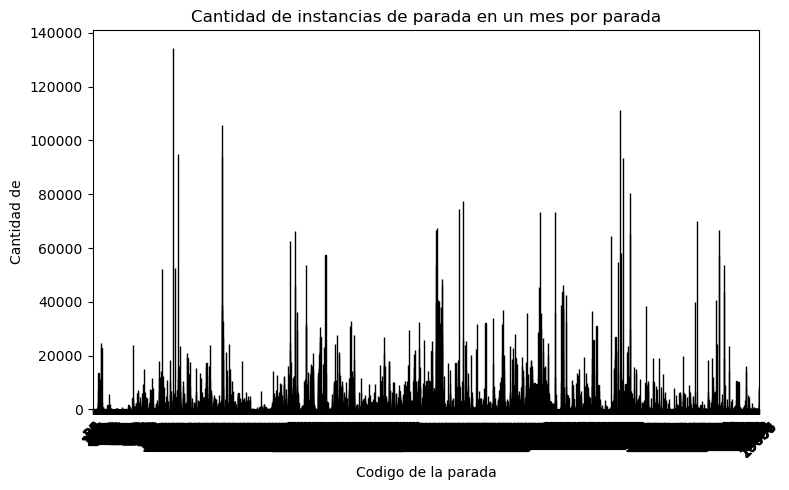

In [39]:
paradas_counts = df["codigo_parada_origen"].value_counts().sort_index()

print(paradas_counts)

plt.figure(figsize=(8,5))
paradas_counts.plot(kind="bar", color="lightcoral", edgecolor="black")

plt.title("Cantidad de instancias de parada en un mes por parada")
plt.xlabel("Codigo de la parada")
plt.ylabel("Cantidad de ")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
display(paradas_counts.head())

codigo_parada_origen
25    17
26     5
27    12
30    11
51     2
Name: count, dtype: int64

In [41]:
print(paradas_counts.get(19606,0))

1895


linea_codigo
1.0       93346
2.0      119529
3.0      323527
4.0       75026
5.0      151613
          ...  
504.0     12890
505.0      7287
506.0      2663
507.0      1801
508.0      3363
Name: count, Length: 136, dtype: int64


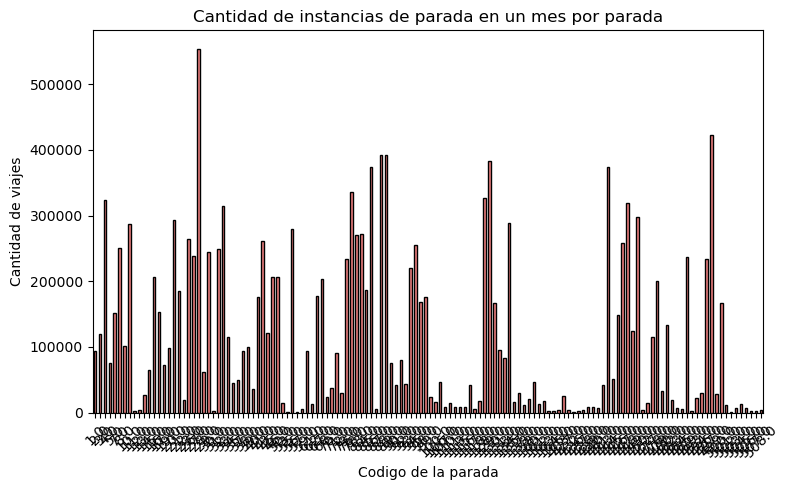

In [42]:
lineas_counts = df["linea_codigo"].value_counts().sort_index()

print(lineas_counts)

plt.figure(figsize=(8,5))
lineas_counts.plot(kind="bar", color="lightcoral", edgecolor="black")

plt.title("Cantidad de instancias de parada en un mes por parada")
plt.xlabel("Codigo de la parada")
plt.ylabel("Cantidad de viajes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
# Elegimos un día (por ejemplo, 2022-01-02)
dia = "2022-01-02"

# Filtramos solo ese día
df_dia = df[df["fecha_evento"].dt.date == pd.to_datetime(dia).date()]

# Elegimos una hora (por ejemplo, la hora 0)
hora = 0

# Filtramos solo los registros dentro de esa hora
df_dia_hora = df_dia[df_dia["fecha_evento"].dt.hour == hora]

display(df_dia_hora.head())

,id_viaje,con_tarjeta,fecha_evento,tipo_viaje,descripcion_tipo_viaje,grupo_usuario,descripcion_grupo_usuario,grupo_usuario_especifico,descripcion_grupo_usuario_espe,ordinal_de_tramo,cantidad_pasajeros,codigo_parada_origen,cod_empresa,descrip_empresa,linea_codigo,dsc_linea,sevar_codigo
2,3,1,2022-01-02 00:15:01-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,2,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0
3,4,0,2022-01-02 00:15:07-03:00,1.0,COMUN,0,NO CORRESPONDE,0,NO CORRESPONDE,0,1,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0
4,5,1,2022-01-02 00:15:18-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0
5,6,1,2022-01-02 00:15:27-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,2,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0
6,7,1,2022-01-02 00:15:38-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,2109,50.0,C.U.T.C.S.A.,76.0,163,3267.0


In [ ]:
linea = 300  # o el código o nombre que quieras

# Filtramos por día y línea
df_linea_dia = df[
    (df["fecha_evento"].dt.date == pd.to_datetime(dia).date()) &
    (df["dsc_linea"] == linea)
]

# Obtenemos las paradas únicas
paradas = df_linea_dia["codigo_parada_origen"].unique()

print(f"Paradas de la línea {linea} el día {dia}:")
print(paradas)

El id del viaje no es único, eso es raro. Investigo porque:

In [45]:
print(df["id_viaje"].nunique())
print(df["id_viaje"].count())

11728829
15468696


In [46]:
# Contamos cuántas veces aparece cada id_viaje
conteo = df["id_viaje"].value_counts()

# Filtramos la serie para quedarnos solo con los que aparecen más de una vez
ids_duplicados = conteo[conteo > 1]

# Imprimimos los primeros resultados para que los veas
print("IDs que aparecen más de una vez y su cantidad:")
display(ids_duplicados.head())

IDs que aparecen más de una vez y su cantidad:


id_viaje
3283408    23
3532395    21
2798231    18
9367762    18
9854743    17
Name: count, dtype: int64

In [47]:
df[df["id_viaje"]==3283408].head(10)

,id_viaje,con_tarjeta,fecha_evento,tipo_viaje,descripcion_tipo_viaje,grupo_usuario,descripcion_grupo_usuario,grupo_usuario_especifico,descripcion_grupo_usuario_espe,ordinal_de_tramo,cantidad_pasajeros,codigo_parada_origen,cod_empresa,descrip_empresa,linea_codigo,dsc_linea,sevar_codigo
3283407,3283408,1,2022-01-10 15:47:58-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,3111,10.0,C.O.E.T.C.,485.0,2,7590.0
15159143,3283408,1,2022-01-10 16:31:47-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,7,1,3182,50.0,C.U.T.C.S.A.,33.0,111,8082.0
15159144,3283408,1,2022-01-10 17:50:28-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,23,1,3093,10.0,C.O.E.T.C.,485.0,2,7576.0
15159145,3283408,1,2022-01-10 16:29:00-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,6,1,3186,50.0,C.U.T.C.S.A.,31.0,109,2406.0
15159146,3283408,1,2022-01-10 17:26:36-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,20,1,3186,50.0,C.U.T.C.S.A.,27.0,103,2408.0
15159147,3283408,1,2022-01-10 17:36:30-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,21,1,3228,50.0,C.U.T.C.S.A.,27.0,103,2409.0
15159148,3283408,1,2022-01-10 17:21:22-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,19,1,3227,10.0,C.O.E.T.C.,485.0,2,7589.0
15159149,3283408,1,2022-01-10 17:13:39-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,17,1,3221,50.0,C.U.T.C.S.A.,23.0,100,242.0
15159150,3283408,1,2022-01-10 17:15:34-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,18,1,3223,50.0,C.U.T.C.S.A.,31.0,109,2421.0
15159151,3283408,1,2022-01-10 16:59:33-03:00,6.0,2 HORAS,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,14,1,4865,50.0,C.U.T.C.S.A.,31.0,109,2406.0


Segun los metadatos, el id_viaje es:

"identifica de forma unica a un viaje dentro del mes. Definiendo por viaje, todos los tramos realizados por el/los pasajeros con un unico pago"

Pero no queda claro que es un tramo.

In [10]:
# Filtrar viajes de lunes a viernes
# 0=Lunes, 1=Martes, ..., 4=Viernes

df['dia_semana'] = df['fecha_evento'].dt.dayofweek
viajes_lun_vie = df[df['dia_semana'].isin([0,1,2,3,4])].copy()

print(f"Cantidad de viajes de lunes a viernes: {len(viajes_lun_vie)}")
display(viajes_lun_vie.head())

Cantidad de viajes de lunes a viernes: 12724626


,id_viaje,con_tarjeta,fecha_evento,tipo_viaje,descripcion_tipo_viaje,grupo_usuario,descripcion_grupo_usuario,grupo_usuario_especifico,descripcion_grupo_usuario_espe,ordinal_de_tramo,cantidad_pasajeros,codigo_parada_origen,cod_empresa,descrip_empresa,linea_codigo,dsc_linea,sevar_codigo,dia_semana
98850,98851,0,2022-01-03 00:02:14-03:00,12.0,MET. ENTRANTE,0,NO CORRESPONDE,0,NO CORRESPONDE,0,1,4763,50.0,C.U.T.C.S.A.,26.0,102,280.0,0
99252,99253,1,2022-01-03 00:05:54-03:00,7.0,EST. A,2,ESTUDIANTE,21,ESTUDIANTE A,1,1,3827,50.0,C.U.T.C.S.A.,76.0,163,1122.0,0
99253,99254,1,2022-01-03 00:08:39-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,2108,50.0,C.U.T.C.S.A.,76.0,163,1122.0,0
99254,99255,1,2022-01-03 00:08:42-03:00,5.0,1 HORA,1,USUARIO CORRIENTE,1,USUARIO CORRIENTE,1,1,2108,50.0,C.U.T.C.S.A.,76.0,163,1122.0,0
99255,99256,0,2022-01-03 00:08:48-03:00,1.0,COMUN,0,NO CORRESPONDE,0,NO CORRESPONDE,0,1,2108,50.0,C.U.T.C.S.A.,76.0,163,1122.0,0


In [11]:
# Calcular horario promedio por parada y línea
# Agrupamos por línea, parada y hora, y calculamos el promedio de horario por día

# Extraer hora de paso
viajes_lun_vie['hora'] = viajes_lun_vie['fecha_evento'].dt.hour
viajes_lun_vie['minuto'] = viajes_lun_vie['fecha_evento'].dt.minute

# Convertir hora:minuto a minutos desde medianoche para promediar
viajes_lun_vie['minutos_desde_medianoche'] = viajes_lun_vie['hora']*60 + viajes_lun_vie['minuto']

# Agrupar por línea, parada, día y hora, y calcular promedio de minutos
promedios = viajes_lun_vie.groupby(['dsc_linea','codigo_parada_origen','hora','dia_semana'])['minutos_desde_medianoche'].mean().reset_index()

# Convertir el promedio de minutos a horario (hh:mm)
promedios['horario'] = promedios['minutos_desde_medianoche'].apply(lambda x: f"{int(x//60):02d}:{int(x%60):02d}")

# Mostrar una muestra del resultado
display(promedios.head())

,dsc_linea,codigo_parada_origen,hora,dia_semana,minutos_desde_medianoche,horario
0,100,25,10,0,636.0,10:36
1,100,25,20,0,1230.0,20:30
2,100,25,23,0,1430.0,23:50
3,100,27,10,0,648.0,10:48
4,100,27,19,0,1167.0,19:27


In [12]:
# Construir dataframe final y exportar a CSV
# El dataframe tendrá: cod_Linea, horario, id_parada

df_horario_teorico = promedios[['dsc_linea', 'horario', 'codigo_parada_origen']].copy()
df_horario_teorico = df_horario_teorico.rename(columns={
    'dsc_linea': 'dsc_linea',
    'codigo_parada_origen': 'id_parada'
})


# Exportar a CSV
output_path = '../horario_teorico.csv'
df_horario_teorico.to_csv(output_path, index=False)
print(f"Archivo guardado en {output_path}")
display(df_horario_teorico.head())

Archivo guardado en ../horario_teorico.csv


,dsc_linea,horario,id_parada
0,100,10:36,25
1,100,20:30,25
2,100,23:50,25
3,100,10:48,27
4,100,19:27,27


In [15]:
print(df_horario_teorico['dsc_linea'].unique())
print(len(df_horario_teorico['dsc_linea']))

['100' '102' '103' '104' '105' '106' '109' '110' '111' '112' '113' '115'
 '116' '117' '121' '124' '124 SD' '125' '127' '128' '130' '133' '135'
 '137' '140' '141' '142' '143' '144' '145' '147' '148' '149' '150' '151'
 '155' '156' '157' '158' '163' '169' '17' '174' '175' '180' '181' '182'
 '183' '185' '186' '187' '188' '191' '192' '195' '199' '2' '21' '300'
 '306' '316' '328' '329' '330' '370' '396' '402' '404' '405' '407' '409'
 '427' '456' '494' '495' '505' '522' '524' '526' '538' '546' '582' '60'
 '62' '64' '71' '76' '79' 'CE1' 'D10' 'D11' 'D5' 'D8' 'D9' 'DE1' 'E14' 'G'
 'G10' 'G11' 'G3' 'G6' 'G8' 'L1' 'L12' 'L13' 'L14' 'L15' 'L16' 'L17' 'L18'
 'L19' 'L2' 'L20' 'L22' 'L23' 'L24' 'L25' 'L26' 'L28' 'L29' 'L3' 'L30'
 'L31' 'L32' 'L33' 'L34' 'L35' 'L36' 'L38' 'L39' 'L4' 'L41' 'L46' 'L5'
 'L6' 'L7']
911049
